In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [10]:
def read_dos(dos_file):
    data = pd.read_csv(dos_file, header=None, names=["x", "xerr", "dos", "doserr", "fit"])
    data = data[["x", "dos"]]
    return data

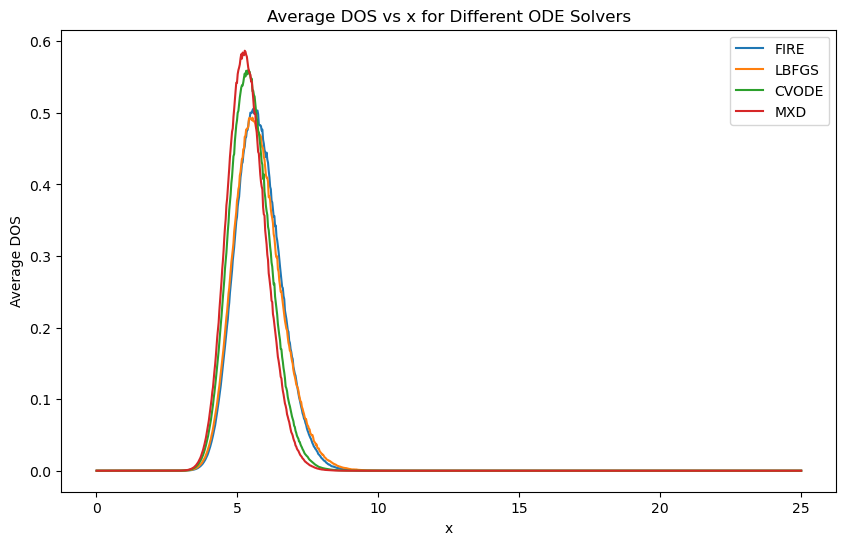

In [12]:
def interpolate_dos(dataframes):
    # Find the common x range across all dataframes
    common_x = np.linspace(min(df['x'].min() for df in dataframes), 
                           25, 
                           num=1000)  # you can adjust the number of points

    interpolated_dfs = []
    for df in dataframes:
        interpolated_df = pd.DataFrame({'x': common_x})
        interpolated_df['dos'] = np.interp(common_x, df['x'], df['dos'])
        interpolated_dfs.append(interpolated_df)

    return interpolated_dfs

def average_dos(directory):
    files = os.listdir(directory)
    grouped_files = {}

    # Group files by ODE solver
    for file in files:
        parts = file.split('_')
        solver = parts[1]
        if solver not in grouped_files:
            grouped_files[solver] = []
        grouped_files[solver].append(os.path.join(directory, file))

    average_dos_data = {}

    for solver, file_paths in grouped_files.items():
        dfs = [read_dos(fp) for fp in file_paths]
        interpolated_dfs = interpolate_dos(dfs)
        average_dos = pd.concat(interpolated_dfs).groupby('x').mean().reset_index()
        average_dos_data[solver] = average_dos

    return average_dos_data

def plot_average_dos(average_dos_data):
    plt.figure(figsize=(10, 6))

    for solver, df in average_dos_data.items():
        plt.plot(df['x'], df['dos'], label=solver)

    plt.xlabel('x')
    plt.ylabel('Average DOS')
    plt.title('Average DOS vs x for Different ODE Solvers')
    plt.legend()
    plt.show()

# Directory path
directory = '/home/praharsh/dos_data_16'

# Calculate average DOS
average_dos_data = average_dos(directory)

# Plotting
plot_average_dos(average_dos_data)